In [29]:
import yfinance as yf
import pandas as pd

In [30]:
eth = yf.download("ETH-USD", start="2018-01-01")
eth.columns = eth.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [31]:
print(eth.head())

Price            Close         High         Low        Open      Volume
Date                                                                   
2018-01-01  772.640991   782.530029  742.004028  755.757019  2595760128
2018-01-02  884.443970   914.830017  772.346008  772.346008  5783349760
2018-01-03  962.719971   974.471008  868.450989  886.000000  5093159936
2018-01-04  980.921997  1045.079956  946.085999  961.713013  6502859776
2018-01-05  997.719971  1075.390015  956.325012  975.750000  6683149824


In [32]:
eth.to_csv("eth_data.csv")

In [33]:
eth = pd.read_csv("eth_data.csv")

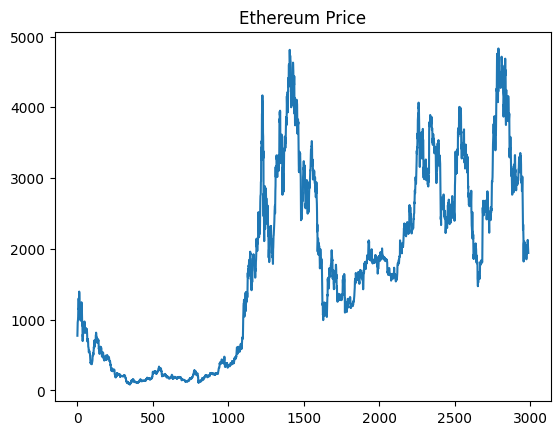

In [34]:
import matplotlib.pyplot as plt

plt.plot(eth['Close'])
plt.title("Ethereum Price")
plt.show()

In [35]:
import numpy as np

eth['returns'] = np.log(eth['Close'] / eth['Close'].shift(1))

In [36]:
eth.head()

,Date,Close,High,Low,Open,Volume,returns
0,2018-01-01,772.640991,782.530029,742.004028,755.757019,2595760128,NaN
1,2018-01-02,884.443970,914.830017,772.346008,772.346008,5783349760,0.135145
2,2018-01-03,962.719971,974.471008,868.450989,886.000000,5093159936,0.084803
3,2018-01-04,980.921997,1045.079956,946.085999,961.713013,6502859776,0.018730
4,2018-01-05,997.719971,1075.390015,956.325012,975.750000,6683149824,0.016980


In [37]:
eth['volatility'] = eth['returns'].rolling(30).std()

In [38]:
eth.head()

,Date,Close,High,Low,Open,Volume,returns,volatility
0,2018-01-01,772.640991,782.530029,742.004028,755.757019,2595760128,NaN,NaN
1,2018-01-02,884.443970,914.830017,772.346008,772.346008,5783349760,0.135145,NaN
2,2018-01-03,962.719971,974.471008,868.450989,886.000000,5093159936,0.084803,NaN
3,2018-01-04,980.921997,1045.079956,946.085999,961.713013,6502859776,0.018730,NaN
4,2018-01-05,997.719971,1075.390015,956.325012,975.750000,6683149824,0.016980,NaN


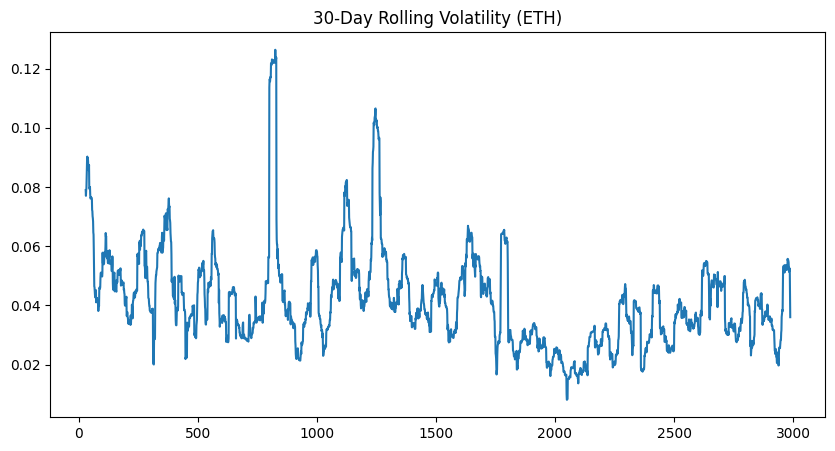

In [39]:
plt.figure(figsize=(10,5))
plt.plot(eth['volatility'])
plt.title("30-Day Rolling Volatility (ETH)")
plt.show()

In [40]:
eth['Vol_Lag1'] = eth['volatility'].shift(1)
eth['Vol_Lag5'] = eth['volatility'].shift(5)
eth['Vol_Lag10'] = eth['volatility'].shift(10)

In [41]:
eth['MA_20'] = eth['Close'].rolling(20).mean()
eth['MA_50'] = eth['Close'].rolling(50).mean()

In [42]:
delta = eth['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
eth['RSI'] = 100 - (100 / (1 + rs))

In [43]:
eth['Volume_MA'] = eth['Volume'].rolling(20).mean()

In [44]:
eth = eth.dropna()

In [45]:
X = eth[['MA_20','MA_50','RSI','Volume_MA','Vol_Lag1',
    'Vol_Lag5',
    'Vol_Lag10'
]]

In [46]:
y = eth['volatility']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [48]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [50]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [51]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

Linear Regression RMSE: 0.0023410883573211625
Random Forest RMSE: 0.002154132439001923
XGBoost RMSE: 0.0025686971406844138


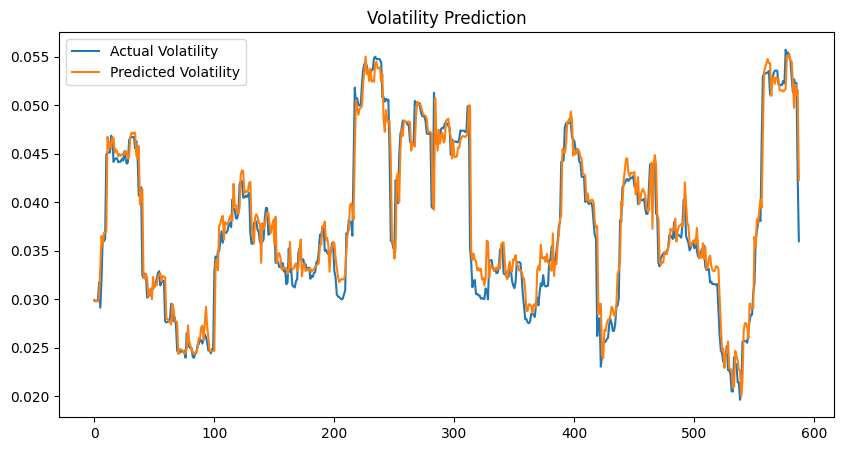

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred_rf, label="Predicted Volatility")
plt.legend()
plt.title("Volatility Prediction")
plt.show()